In [ ]:
!uname -a && cat /etc/*release

Linux 419e23c9cc2b 6.6.113+ #1 SMP Mon Feb  2 12:27:57 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux
DISTRIB_ID=Ubuntu
DISTRIB_RELEASE=22.04
DISTRIB_CODENAME=jammy
DISTRIB_DESCRIPTION="Ubuntu 22.04.5 LTS"
PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [ ]:
!pwd
!ls -la

/content
total 64
drwxr-xr-x 1 root root 4096 Mar 10 09:59 .
drwxr-xr-x 1 root root 4096 Mar 10 09:45 ..
drwxr-xr-x 2 root root 4096 Mar 10 09:50 bin
drwxr-xr-x 4 root root 4096 Feb  6 14:31 .config
drwxr-xr-x 2 root root 4096 Mar 10 09:49 .ipynb_checkpoints
-rw-r--r-- 1 root root 4051 Mar 10 09:46 matmul_cuda_cublas.cu
-rw-r--r-- 1 root root 3927 Mar 10 09:46 matmul_cuda_cublas_floats.cu
-rw-r--r-- 1 root root 5142 Mar 10 09:46 matmul_cuda_floats.cu
-rw-r--r-- 1 root root 2830 Mar 10 09:59 matmul_cuda_naive.cu
-rw-r--r-- 1 root root 2825 Mar 10 09:59 matmul_cuda_naive_floats.cu
-rw-r--r-- 1 root root 5098 Mar 10 09:46 matmul_cuda_shared.cu
-rw-r--r-- 1 root root  215 Mar 10 09:48 results_4100.csv
-rw-r--r-- 1 root root  215 Mar 10 09:50 results.csv
drwxr-xr-x 1 root root 4096 Feb  6 14:31 sample_data


In [ ]:
!nvidia-smi

Tue Mar 10 10:01:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvidia-smi topo -m

	GPU0	CPU Affinity	NUMA Affinity	GPU NUMA ID
GPU0	 X 	0-1	0		N/A

Legend:

  X    = Self
  SYS  = Connection traversing PCIe as well as the SMP interconnect between NUMA nodes (e.g., QPI/UPI)
  NODE = Connection traversing PCIe as well as the interconnect between PCIe Host Bridges within a NUMA node
  PHB  = Connection traversing PCIe as well as a PCIe Host Bridge (typically the CPU)
  PXB  = Connection traversing multiple PCIe bridges (without traversing the PCIe Host Bridge)
  PIX  = Connection traversing at most a single PCIe bridge
  NV#  = Connection traversing a bonded set of # NVLinks


In [ ]:
!lstopo

/bin/bash: line 1: lstopo: command not found


In [ ]:
#!nvcc -arch=sm_75 -O3 -DTIME -DALIGN -DRESTRICT -DN=20500 -DTILE_SIZE=32 matmul_cuda_shared.cu -o matmul_cuda

!nvcc -arch=sm_75 -O3 -DTIME -DALIGN -DRESTRICT -DN=8192 -DTILE_SIZE=32 -DCOARSE_FACTOR=4 matmul_cuda_coarse.cu -o matmul_coarse

#!nvcc -arch=sm_75 -O3 -DTIME -DALIGN -DRESTRICT -DN=20500 matmul_cuda_cublas.cu -o matmul_cublas -lcublas

In [ ]:
# 4096  - cublas - 0.665
# 4100  - cublas - 0.572
# 8192  - cublas - 4.465
# 8200  - cublas - 4.588
# 12288 - cublas - 15.330
# 12300 - cublas - 15.651
# 16384 - cublas - 36.145
# 16400 - cublas - 36.432
# 20480 - cublas - 70.088
# 20500 - cublas - 70.839

In [ ]:
# 4096  - 16 - 0.701  - 32 - 0.647
# 4100  - 16 - 0.782  - 32 - 0.678
# 8192  - 16 - 5.277  - 32 - 4.958
# 8200  - 16 - 5.493  - 32 - 4.994
# 12288 - 16 - 18.372 - 32 - 16.227
# 12300 - 16 - 19.349 - 32 - 16.742
# 16384 - 16 - 47.448 - 32 - 40.400
# 16400 - 16 - 47.541 - 32 - 40.118
# 20480 - 16 - 92.274 - 32 - 80.507
# 20500 - 16 - 95.580 - 32 - 80.207


In [ ]:
%%bash

# 1. Setup Matrix Sizes and Base Compilation Flags
MATRIX_SIZES=(4100 8200 12300 16400)
ARCH="-arch=sm_75"
FLAGS="-O3 $ARCH -DTIME -DENABLE_TIMING"

# 2. Initialize the CSV file with new headers
echo "MatrixSize,Algorithm,Precision,Config,Time(Seconds)" > results_full.csv
mkdir -p bin

# --- CONFIGURATIONS ---
# Naive configs (X Y) - Testing coalescing and occupancy
configs_naive=(
    "16 16"
    "32 8"
    "32 16"
    "32 32"
)

# Shared Double configs (X Y K)
configs_shared_double=(
    "16 16 16"
    "32 8 16"
    "32 16 16"
    "32 32 16"
)

# Shared Float configs (X Y K)
configs_shared_float=(
    "32 16 16"
    "32 16 32"
    "64 8 32"
    "32 16 64"
)

for N in "${MATRIX_SIZES[@]}"; do
    echo "=========================================="
    echo " TESTING MATRIX SIZE: $N x $N "
    echo "=========================================="

    # --- A. NAIVE BASELINES ---
    echo ">>> Running Naive Baselines..."
    for conf in "${configs_naive[@]}"; do
        read -r x y <<< "$conf"

        # # Double
        # nvcc $FLAGS -DN=$N -DTILE_X=$x -DTILE_Y=$y matmul_cuda_naive.cu -o bin/naive_double_${x}_${y}_${N}
        # OUTPUT=$(./bin/naive_double_${x}_${y}_${N})
        # TIME=$(echo "$OUTPUT" | grep -oP 'elapsed=\K[0-9.]+')
        # echo "$N,Naive,Double,${x}x${y},$TIME" >> results_full.csv

        # Float
        nvcc $FLAGS -DN=$N -DTILE_X=$x -DTILE_Y=$y matmul_cuda_naive_floats.cu -o bin/naive_float_${x}_${y}_${N}
        OUTPUT=$(./bin/naive_float_${x}_${y}_${N})
        TIME=$(echo "$OUTPUT" | grep -oP 'elapsed=\K[0-9.]+')
        echo "$N,Naive,Float,${x}x${y},$TIME" >> results_full.csv
    done

    # # --- B. SHARED MEMORY (DOUBLE) ---
    # echo ">>> Running Shared Memory (Double)..."
    # for conf in "${configs_shared_double[@]}"; do
    #     read -r x y k <<< "$conf"
    #     nvcc $FLAGS -DN=$N -DTILE_X=$x -DTILE_Y=$y -DTILE_K=$k matmul_cuda_shared.cu -o bin/shared_double_${x}_${y}_${k}_${N}
    #     OUTPUT=$(./bin/shared_double_${x}_${y}_${k}_${N})
    #     TIME=$(echo "$OUTPUT" | grep -oP 'elapsed=\K[0-9.]+')
    #     echo "$N,Shared,Double,${x}x${y}x${k},$TIME" >> results_full.csv
    # done

    # # --- C. SHARED MEMORY (FLOAT) ---
    # echo ">>> Running Shared Memory (Float)..."
    # for conf in "${configs_shared_float[@]}"; do
    #     read -r x y k <<< "$conf"
    #     nvcc $FLAGS -DN=$N -DTILE_X=$x -DTILE_Y=$y -DTILE_K=$k matmul_cuda_floats.cu -o bin/shared_float_${x}_${y}_${k}_${N}
    #     OUTPUT=$(./bin/shared_float_${x}_${y}_${k}_${N})
    #     TIME=$(echo "$OUTPUT" | grep -oP 'elapsed=\K[0-9.]+')
    #     echo "$N,Shared,Float,${x}x${y}x${k},$TIME" >> results_full.csv
    # done
    # echo ""
done

echo "Benchmarks Complete! Final CSV Results:"
cat results_full.csv

 TESTING MATRIX SIZE: 4100 x 4100 
>>> Running Naive Baselines...
 TESTING MATRIX SIZE: 8200 x 8200 
>>> Running Naive Baselines...
 TESTING MATRIX SIZE: 12300 x 12300 
>>> Running Naive Baselines...
 TESTING MATRIX SIZE: 16400 x 16400 
>>> Running Naive Baselines...
Benchmarks Complete! Final CSV Results:
MatrixSize,Algorithm,Precision,Config,Time(Seconds)
4100,Naive,Float,16x16,0.343
4100,Naive,Float,32x8,0.444
4100,Naive,Float,32x16,0.306
4100,Naive,Float,32x32,0.264
8200,Naive,Float,16x16,3.202
8200,Naive,Float,32x8,4.954
8200,Naive,Float,32x16,2.344
8200,Naive,Float,32x32,2.207
12300,Naive,Float,16x16,17.004
12300,Naive,Float,32x8,25.907
12300,Naive,Float,32x16,10.607
12300,Naive,Float,32x32,10.835
16400,Naive,Float,16x16,101.082
16400,Naive,Float,32x8,122.989
16400,Naive,Float,32x16,26.047
16400,Naive,Float,32x32,29.259


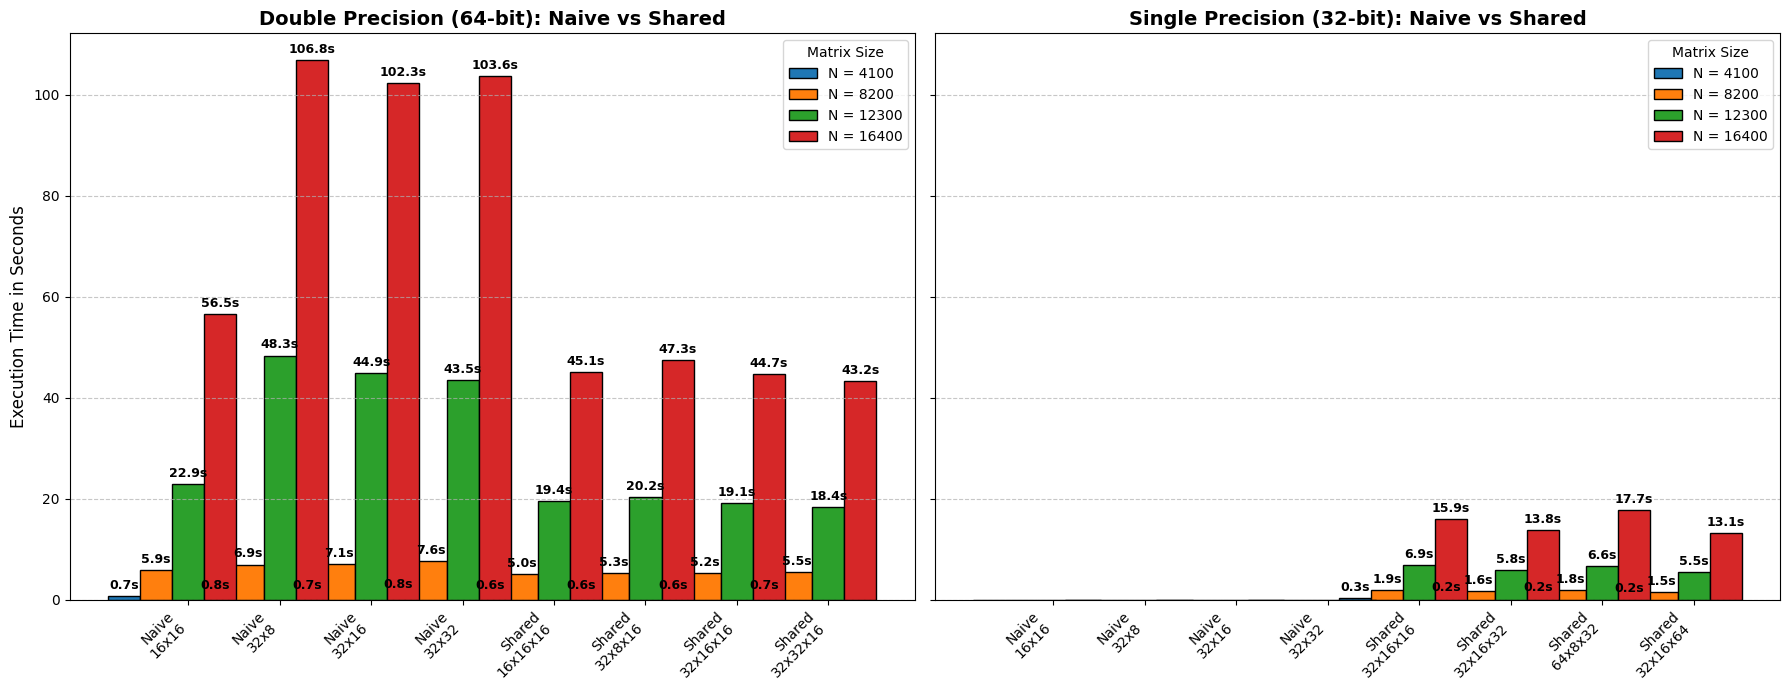

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the results
try:
    df = pd.read_csv('results_full.csv')
except FileNotFoundError:
    print("Error: 'results_full.csv' not found.")
    exit()

df['Label'] = df['Algorithm'] + '\n' + df['Config']

# Get unique matrix sizes
sizes = sorted(df['MatrixSize'].unique())
width = 0.35

# 2. Set up a side-by-side figure (Left: Double, Right: Float)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Helper function to plot grouped bars on a specific axis
def plot_data(ax, data, title, is_ylabel_needed=False):
    labels = data['Label'].unique()
    x = np.arange(len(labels))

    for i, N in enumerate(sizes):
        subset = data[data['MatrixSize'] == N]
        # Reindex to ensure bars match the exact order of labels
        subset = subset.set_index('Label').reindex(labels)
        times = subset['Time(Seconds)'].fillna(0).values

        offset = (i - 0.5) * width if len(sizes) == 2 else (i - len(sizes)/2) * width
        rects = ax.bar(x + offset, times, width, label=f'N = {N}', edgecolor='black')

        # Add values on top of bars
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}s',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if is_ylabel_needed:
        ax.set_ylabel('Execution Time in Seconds', fontsize=12)
    ax.legend(title='Matrix Size')

# 3. Plot Double Precision on the Left
df_double = df[df['Precision'] == 'Double']
plot_data(ax1, df_double, 'Double Precision (64-bit): Naive vs Shared', is_ylabel_needed=True)

# 4. Plot Single Precision (Float) on the Right
df_float = df[df['Precision'] == 'Float']
plot_data(ax2, df_float, 'Single Precision (32-bit): Naive vs Shared')

plt.tight_layout()
plt.show()

In [ ]:
%%bash

# 1. Setup Matrix Sizes and Base Compilation Flags
MATRIX_SIZES=(4100 8200 12300 16400)
ARCH="-arch=sm_75"
FLAGS="-O3 $ARCH -DTIME -DENABLE_TIMING"

# 2. Initialize the CSV file with new headers
echo "MatrixSize,Precision,Config,Time" > results_multi.csv
mkdir -p bin

for N in "${MATRIX_SIZES[@]}"; do
    echo "=========================================="
    echo " TESTING MATRIX SIZE: $N x $N "
    echo "=========================================="

    # --- A. cuBLAS BASELINES ---
    echo "[Compiling] cuBLAS Double..."
    nvcc $FLAGS -DN=$N matmul_cuda_cublas.cu -o bin/cublas_double_$N -lcublas
    OUTPUT=$(./bin/cublas_double_$N)
    TIME=$(echo "$OUTPUT" | grep -oP 'elapsed=\K[0-9.]+')
    echo "$N,Double,cuBLAS,$TIME" >> results_multi.csv

    echo "[Compiling] cuBLAS Float..."
    nvcc $FLAGS -DN=$N matmul_cuda_cublas_floats.cu -o bin/cublas_float_$N -lcublas
    OUTPUT=$(./bin/cublas_float_$N)
    TIME=$(echo "$OUTPUT" | grep -oP 'elapsed=\K[0-9.]+')
    echo "$N,Float,cuBLAS,$TIME" >> results_multi.csv
done

echo "Benchmarks Complete! Final CSV Results:"
cat results_multi.csv

 TESTING MATRIX SIZE: 4100 x 4100 
[Compiling] cuBLAS Double...
[Compiling] cuBLAS Float...
 TESTING MATRIX SIZE: 8200 x 8200 
[Compiling] cuBLAS Double...
[Compiling] cuBLAS Float...
 TESTING MATRIX SIZE: 12300 x 12300 
[Compiling] cuBLAS Double...
[Compiling] cuBLAS Float...
 TESTING MATRIX SIZE: 16400 x 16400 
[Compiling] cuBLAS Double...
[Compiling] cuBLAS Float...
Benchmarks Complete! Final CSV Results:
MatrixSize,Precision,Config,Time
4100,Double,cuBLAS,0.687
4100,Float,cuBLAS,0.055
8200,Double,cuBLAS,4.571
8200,Float,cuBLAS,0.307
12300,Double,cuBLAS,14.985
12300,Float,cuBLAS,0.875
16400,Double,cuBLAS,35.138
16400,Float,cuBLAS,2.100


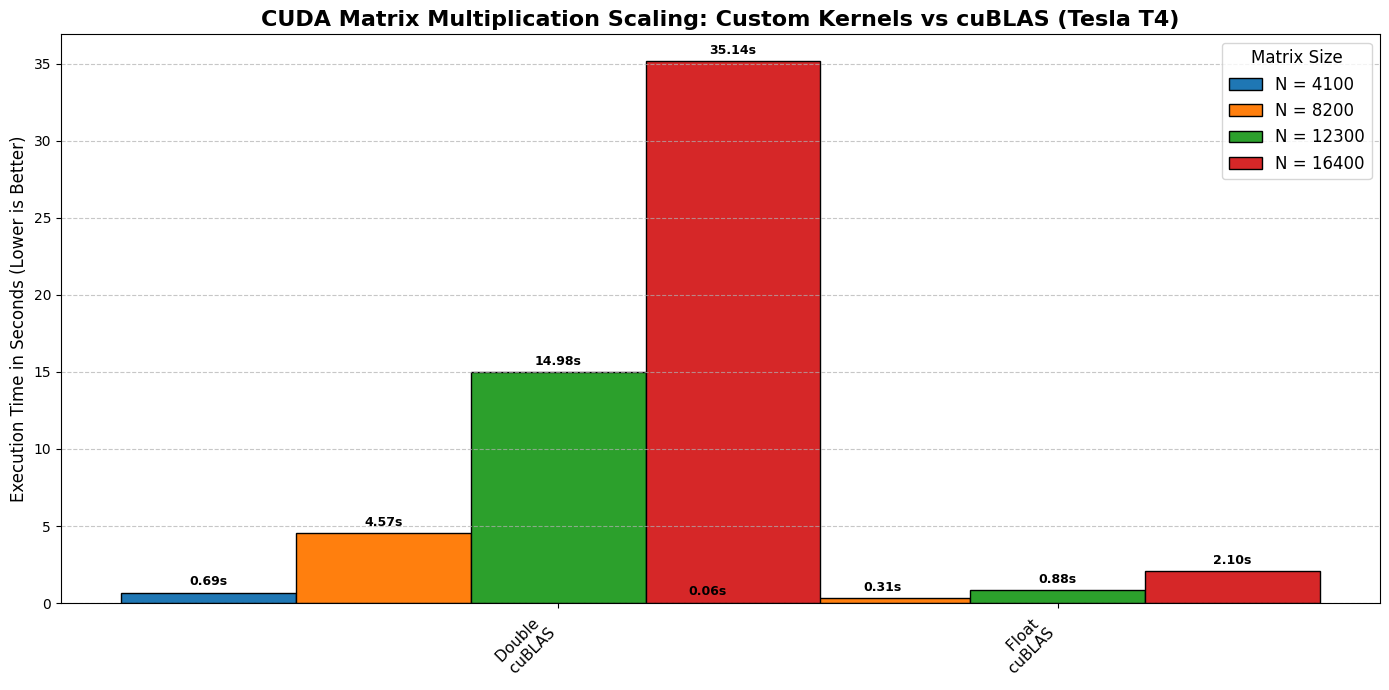

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the results
try:
    df = pd.read_csv('results_multi.csv')
except FileNotFoundError:
    print("Error: 'results_multi.csv' not found.")
    exit()

# 2. Create a unified label for sorting and display
df['Label'] = df['Precision'] + ' \n ' + df['Config']

# Group the data to create grouped bar charts
sizes = sorted(df['MatrixSize'].unique())
labels = df['Label'].unique()

# 3. Set up the plot
x = np.arange(len(labels))
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(14, 7))

# Plot bars for each matrix size
for i, N in enumerate(sizes):
    # Filter data for this specific matrix size
    subset = df[df['MatrixSize'] == N]

    # Ensure the order matches our labels array
    subset = subset.set_index('Label').reindex(labels)
    times = subset['Time'].fillna(0).values # Fill NA with 0 just in case a test failed

    # Offset the bars so they sit side-by-side
    offset = (i - 0.5) * width if len(sizes) == 2 else (i - len(sizes)/2) * width
    rects = ax.bar(x + offset, times, width, label=f'N = {N}', edgecolor='black')

    # Add text labels on top of the bars
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}s',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Styling
ax.set_ylabel('Execution Time in Seconds (Lower is Better)', fontsize=12)
ax.set_title('CUDA Matrix Multiplication Scaling: Custom Kernels vs cuBLAS (Tesla T4)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.legend(title='Matrix Size', fontsize=12, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
!/content/matmul_coarse

[cuda-coarse] N=8192, TILE_SIZE=32, COARSE_FACTOR=4 | elapsed=4.562 s


In [ ]:
!nvprof /content/matmul_coarse

==27385== NVPROF is profiling process 27385, command: /content/matmul_coarse
[cuda-coarse] N=8192, TILE_SIZE=32, COARSE_FACTOR=4 | elapsed=4.585 s
==27385== Profiling application: /content/matmul_coarse
==27385== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   92.83%  4.58459s         1  4.58459s  4.58459s  4.58459s  matmul_kernel_coarse(double const *, double const *, double*, int)
                    4.56%  225.26ms         2  112.63ms  112.07ms  113.20ms  [CUDA memcpy HtoD]
                    2.61%  129.01ms         1  129.01ms  129.01ms  129.01ms  [CUDA memcpy DtoH]
      API calls:   90.42%  4.58462s         1  4.58462s  4.58462s  4.58462s  cudaEventSynchronize
                    7.00%  355.16ms         3  118.39ms  112.30ms  129.46ms  cudaMemcpy
                    2.44%  123.68ms         2  61.841ms     697ns  123.68ms  cudaEventCreate
                    0.10%  4.8618ms         3  1.6206ms  406.58us  2.355

In [ ]:
# !/content/matmul_cublas

In [ ]:
# !nvprof /content/matmul_cublas